# Step 1 — Data Cleaning & EDA

Loads 
We will now load the *"Sentiment Analysis for Mental Health"* the raw Kaggle  CSV, clean it, and
checks the class distribution against the paper's Table I. The data was placed in `/data/raw` and will be processed into `/data/processed` 


**Privacy note:** we will not commit the data on github, since they are sensitive and there was no proper redistribution license on Kaggle regarding this dataset. The Jupiter notebooks might leak some row but we are taking that as minimal and no effecting.

In [1]:
import os
while not os.path.isdir("src"):
    os.chdir("..")
print("Working directory set to repo root:", os.getcwd())

Working directory set to repo root: /Users/sadmanshaharier/Documents/CODING - Mac/git repo projects/IUT-CSE/Design Project/TherapyLM-Design-Project


In [2]:
import sys
sys.path.append("src")   # so we can import our own modules below

import matplotlib.pyplot as plt
%matplotlib inline

from clean_data import clean_dataset, print_class_distribution, CATEGORIES

## Clean the raw data
`clean_dataset()` strips URLs/HTML, removes unsupported characters, drops posts under 10 characters, and keeps only the 7 known labels. Thus exactly reproducing the paper's preprocessing.

In [3]:
df = clean_dataset(
    input_path="data/raw/Combined_Data.csv",
    output_path="data/processed/clean.csv",
)
df.shape   # (rows, columns) -- should be roughly (52000-ish, 2)

Loaded 53043 raw rows. Columns: ['Unnamed: 0', 'statement', 'status']

Saved 50726 cleaned rows to data/processed/clean.csv


(50726, 2)

## Class distribution
This is to compare percentages to the paper's Table I (Normal ~31%, Depression ~29%, Suicidal ~20%, Anxiety ~7%, Bipolar ~5%, Stress ~5%, Personality disorder ~2%).


In [4]:
print_class_distribution(df)

Class distribution:
  Normal                  15712  (31.0%)
  Depression              15084  (29.7%)
  Suicidal                10638  (21.0%)
  Anxiety                  3609  (7.1%)
  Bipolar                  2501  (4.9%)
  Stress                   2288  (4.5%)
  Personality disorder      894  (1.8%)


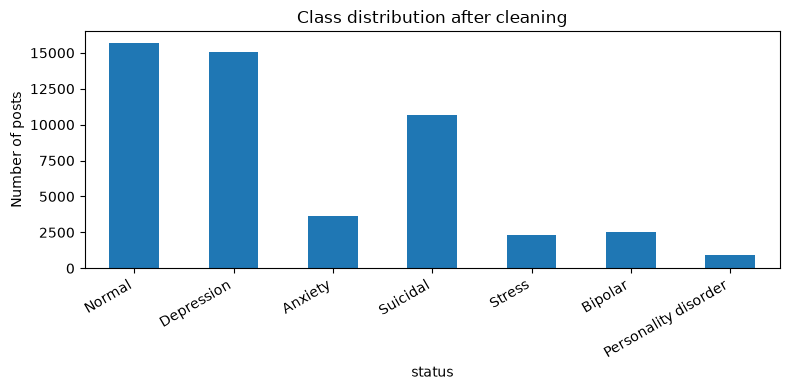

In [5]:
# Bar chart version for the slides
os.makedirs("results/figures", exist_ok=True)
counts = df["status"].value_counts().reindex(CATEGORIES)
plt.figure(figsize=(8, 4))
counts.plot(kind="bar")
plt.title("Class distribution after cleaning")
plt.ylabel("Number of posts")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("results/figures/class_distribution.png", dpi=120)
plt.show()

## Done
`data/processed/clean.csv` is saved. I will now move on  **`02_train_classical_models.ipynb`**.